In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [23]:
teq = 1000
comp = "asplund_m3"
TOA = pd.read_csv(f"output/grid_day/{teq}K_{comp}_day/{teq}K_{comp}_day_TOA_flux_eclipse.dat", sep="\\s+", skiprows=2)

In [24]:
TOA

,bin,cent_lambda[um],low_int_lambda[um],delta_lambda[um],F_down_at_TOA,F_up_at_TOA,planet/star,flux,ratio
0,0,0.246440,0.244000,0.004880,1.674750e+09,8.002340e+08,0.000005,NaN,NaN
1,1,0.251369,0.248880,0.004978,2.123840e+09,9.784080e+08,0.000005,NaN,NaN
2,2,0.256396,0.253858,0.005077,2.675630e+09,1.186940e+09,0.000005,NaN,NaN
3,3,0.261524,0.258935,0.005179,3.349070e+09,1.428970e+09,0.000005,NaN,NaN
4,4,0.266755,0.264113,0.005282,4.165510e+09,1.707620e+09,0.000004,NaN,NaN
...,...,...,...,...,...,...,...,...,...
380,380,456.852988,452.329691,9.046594,1.980420e+02,6.077550e+03,0.000334,NaN,NaN
381,381,465.990048,461.376285,9.227526,1.817110e+02,5.623570e+03,0.000336,NaN,NaN
382,382,475.309849,470.603811,9.412076,1.666990e+02,5.190100e+03,0.000338,NaN,NaN
383,383,484.816046,480.015887,9.600318,1.529020e+02,4.801210e+03,0.000341,NaN,NaN


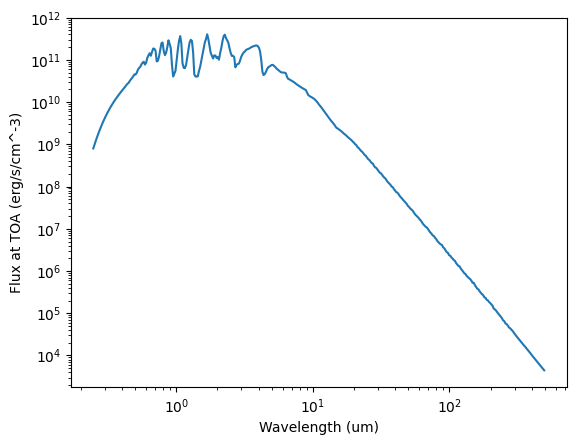

In [25]:
plt.plot(TOA["cent_lambda[um]"], TOA["F_up_at_TOA"])
plt.xlabel("Wavelength (um)")
plt.ylabel("Flux at TOA (erg/s/cm^-3)")
plt.xscale("log")
plt.yscale("log")

In [26]:
#fit a blackbody to the TOA flux
from scipy.optimize import curve_fit

In [31]:
def blackbody_lambda(wavelength, T):
    # wavelength in microns, T in K
    # output in erg/s/cm^3
    c1 = 1.191e15 #erg/s/cm^3
    c2 = 14387.8

    return np.pi * c1 * (wavelength**-5) / (np.exp(c2/(wavelength*T)) - 1)

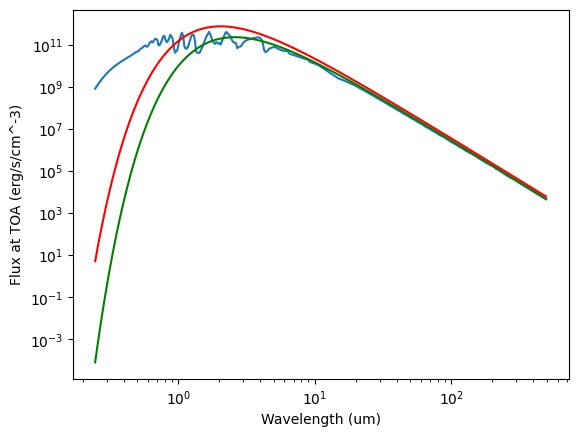

In [32]:
plt.plot(TOA["cent_lambda[um]"], TOA["F_up_at_TOA"])
plt.xlabel("Wavelength (um)")
plt.ylabel("Flux at TOA (erg/s/cm^-3)")
plt.xscale("log")
plt.yscale("log")
plt.plot(TOA["cent_lambda[um]"], blackbody_lambda(TOA["cent_lambda[um]"], 1116.8), label="true brightness", color="green")
plt.plot(TOA["cent_lambda[um]"], blackbody_lambda(TOA["cent_lambda[um]"], 1416.5), label="true brightness", color="red")

In [33]:
curve_fit(blackbody_lambda, TOA["cent_lambda[um]"], TOA["F_up_at_TOA"], p0=[1700])

(array([1122.35250873]), array([[94.04604085]]))